In [1]:
import os
import copy
from copy import deepcopy
import time
import glob
import random
import pickle
import collections
import itertools
import numpy as np
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from joypy import joyplot
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.cluster import KMeans
from scipy.special import ive
from spherecluster import VonMisesFisherMixture
import sklearn.covariance
import openood.utils.comm as comm
from openood.utils import config
from openood.networks.resnet18_32x32 import ResNet18_32x32
from openood.datasets import get_dataloader, get_ood_dataloader
from openood.evaluators.metrics import compute_all_metrics
from openood.networks.vae import ConditionalVAE, weighted_average

# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'  # 数学字体使用 Computer Modern
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 设备和随机种子配置
os.environ['PYTHONHASHSEED'] = str(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 添加时间记录
begin_time = time.time()

best_loss = 100
best_epoch_idx = 0
best_acc = 0
best_epoch_idx = 0

In [2]:
class Config_EPA:
    def __init__(self):
        # 训练参数
        self.num_classes = 11  # 修改为16个ID类别
        self.feature_dim = 512
        self.epochs = 100       # 增加训练轮次
        self.batch_size = 128
        # 路径参数
        self.save_dir = "results/rml201610a_comix"
        self.device = device
        # 配置文件
        self.config_files = [
            './configs/datasets/rml201610a_comix/rml201610a.yml',
            './configs/networks/resnet18_32x32.yml',
            './configs/pipelines/test/test_ood.yml',
            './configs/preprocessors/base_preprocessor.yml',
            './configs/postprocessors/msp.yml',
        ]

In [3]:
class ETF_Classifier(nn.Module):
    def __init__(self, feat_in, num_classes, fix_bn=False, LWS=False, reg_ETF=False):
        super(ETF_Classifier, self).__init__()
        effective_classes = num_classes   # 前9个有效类
        P = self.generate_random_orthogonal_matrix(feat_in, effective_classes)
        I = torch.eye(effective_classes)
        one = torch.ones(effective_classes, effective_classes)
        scaling_factor = np.sqrt(effective_classes / (effective_classes - 1))
        self.ori_M = scaling_factor * torch.matmul(P, I - (1.0 / effective_classes) * one).cuda()
        self.ori_M.requires_grad_(False)
        self.LWS = LWS
        self.reg_ETF = reg_ETF

        if fix_bn:
            self.BN_H.weight.requires_grad = False
            self.BN_H.bias.requires_grad = False

    def generate_random_orthogonal_matrix(self, feat_in, num_classes):
        """生成随机正交矩阵"""
        a = np.random.random(size=(feat_in, num_classes))
        P, _ = np.linalg.qr(a)
        P = torch.tensor(P).float()
        return P

    def generate_orthogonal_noise(self, M_signal):
        """生成与信号空间正交的噪声向量"""
        u = torch.randn(M_signal.size(0), 1, device=M_signal.device)
        for i in range(M_signal.size(1)):
            u = u - (u.t() @ M_signal[:, i:i+1]) * M_signal[:, i:i+1]
        noise_vec = u / torch.norm(u)
        return noise_vec
    
    def orthogonal_complement(self):
        feat_dim = self.ori_M.shape[0]
        class_dim = self.ori_M.shape[1]
        weight_basis = self.ori_M.T.cpu()  # 转置使每行成为一个基向量
        full_basis = torch.eye(feat_dim)
        complement_basis = []
        for i in range(feat_dim):
            v = full_basis[i]
            v_copy = v.clone()
            for w in weight_basis:
                v_copy = v_copy - torch.dot(v_copy, w) * w / torch.dot(w, w)
            if torch.norm(v_copy) > 1e-6:
                v_copy = v_copy / torch.norm(v_copy)
                complement_basis.append(v_copy)
        if complement_basis:
            orthogonal_complement = torch.stack(complement_basis)
        else:
            orthogonal_complement = torch.zeros((0, feat_dim))      
        return orthogonal_complement
    
    def project_to_complement(self, x):
        orthogonal_comp = self.orthogonal_complement().cuda()
        projection = torch.matmul(torch.matmul(x, orthogonal_comp.t()), orthogonal_comp)
        return projection
    
    def forward(self, x):

        logit = x @ self.ori_M  # 计算logits
        return logit

In [4]:
def load_model(model,checkpoint_path):
    state_dict = torch.load(checkpoint_path)
    model.load_state_dict(state_dict)
    return model 

In [5]:
def test_orthogonal_complement():
    """测试正交互补子空间的计算是否正确"""
    # 创建一个小型测试实例
    feat_dim = 512
    num_classes = 16
    classifier = ETF_Classifier(feat_dim, num_classes)
    
    # 获取权重矩阵和计算的正交互补子空间
    weight_matrix = classifier.ori_M
    orthogonal_complement = classifier.orthogonal_complement()
    
    print(f"特征维度: {feat_dim}")
    print(f"类别数量: {num_classes} (有效类别)")  # 修正：移除了-1
    print(f"权重矩阵形状: {weight_matrix.shape}")
    print(f"正交互补子空间形状: {orthogonal_complement.shape}")
    
    # 测试1: 检查正交性
    # 计算权重矩阵的每一列与正交互补子空间的每一行的点积
    # 如果它们正交，所有点积应该接近零
    dot_products = torch.matmul(orthogonal_complement, weight_matrix)
    max_dot_product = torch.max(torch.abs(dot_products)).item()
    print(f"最大点积绝对值: {max_dot_product:.8f} (应接近0)")
    
    # 测试2: 检查维度
    # 计算权重矩阵的秩
    _, S, _ = torch.svd(weight_matrix)
    rank_weights = torch.sum(S > 1e-6).item()
    
    # 正交互补子空间的维度
    dim_complement = orthogonal_complement.shape[0]
    
    print(f"权重矩阵的秩: {rank_weights}")
    print(f"正交互补子空间的维度: {dim_complement}")
    print(f"总和: {rank_weights + dim_complement} (应等于特征维度 {feat_dim})")
    
    # 测试3: 验证投影功能
    # 创建一个随机向量
    random_vector = torch.randn(1, feat_dim)
    
    # 将其投影到正交互补子空间
    projected = classifier.project_to_complement(random_vector)
    
    # 检查投影后的向量与权重矩阵的正交性
    projection_dot_products = torch.matmul(projected, weight_matrix)
    max_proj_dot = torch.max(torch.abs(projection_dot_products)).item()
    print(f"投影向量与权重的最大点积绝对值: {max_proj_dot:.8f} (应接近0)")
    
    return max_dot_product < 1e-5 and (rank_weights + dim_complement == feat_dim) and max_proj_dot < 1e-5
    

In [6]:
class AdaptiveModulationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ResNet18_32x32(num_classes=config_epa.num_classes)
        self.classifier = ETF_Classifier(config_epa.feature_dim, config_epa.num_classes)

    def forward(self, x):
        _, features = self.encoder(x)
        return self.classifier(features), features

In [7]:
class TrainingManager:
    def __init__(self, model):
        self.model = model.to(device)
        self.ce = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam([
            {'params': self.model.encoder.parameters(), 'lr': 1e-3},  # 基础学习率
        ])
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=100)
    
    def train_phase1(self, train_loader, val_loader):
        global best_acc, best_epoch_idx
        best_acc = 0
        best_epoch_idx = 0

        for epoch in range(config_epa.epochs):
   
            train_metrics = self.train_epoch(train_loader, epoch + 1)
            val_metrics = eval_acc(self.model, val_loader, epoch + 1)
            save_model(self.model,  val_metrics, config_epa.epochs)
            report(train_metrics, val_metrics)

    def train_epoch(self, loader, epoch):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        
        print(f"Number of batches in epoch {epoch}: {len(loader)}")
        
        for batch in tqdm(loader, desc=f'Epoch {epoch}'):
            x, y = batch['data'].to(device), batch['label'].to(device)
  
            # 分支F的前向传播和反向传播
            self.optimizer.zero_grad()
            logits, features = self.model(x)
            loss = self.ce(logits, y)
            loss.backward()
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()

            _, pred = torch.max(logits, dim=1)  # 选择距离最小的索引
            correct += (pred == y).sum().item()
            total += y.size(0)

        metrics = {
            'epoch_idx': epoch,
            'loss': total_loss / len(loader),
            'acc': correct / total
        }
        return metrics

In [8]:
def eval_acc(model, data_loader, epoch_idx):
    data_loaders = data_loader if isinstance(data_loader, list) else [data_loader]

    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        val_data_loader = iter(data_loader)
        for train_step in tqdm(range(1, len(val_data_loader) + 1),
                                desc='Eval: ', position=0, leave=True):
            batch = next(val_data_loader)
            x = batch['data'].to(device)
            y = batch['label'].to(device)



            logits, _ = model(x)
            loss = F.cross_entropy(logits, y)
            _, pred = torch.max(logits, dim=1)  # 获取最小距离及其对应的索引作为预测
            
            total_correct += (pred == y).sum().item()
            total_samples += y.size(0)
            total_batches += 1
            total_loss += loss.item()
             
    metrics = {}
    metrics['epoch_idx'] = epoch_idx
    metrics['loss'] = save_metrics(total_loss / len(data_loader))
    metrics['acc'] = save_metrics(total_correct / total_samples)
    return metrics

In [9]:
def save_metrics(value):
    all_values = comm.gather(value)
    return sum(all_values)

In [10]:
def save_model(net, val_metrics, num_epochs):
    global best_acc, best_epoch_idx
    output_dir = config_epa.save_dir
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir), exist_ok=True)
    try:
        state_dict = net.module.state_dict()
    except AttributeError:
        state_dict = net.state_dict()


    if val_metrics['acc'] >= best_acc :
        best_epoch_idx = val_metrics['epoch_idx']
        best_acc = val_metrics['acc']
        old_fname = f'best_epoch{best_epoch_idx}_acc{best_acc:.4f}.ckpt'
        old_pth = os.path.join(output_dir, old_fname)
        Path(old_pth).unlink(missing_ok=True)

        best_epoch_idx = val_metrics['epoch_idx']
        best_acc = val_metrics['acc']

        torch.save(state_dict, os.path.join(output_dir,'best.ckpt'))
        save_fname = f'best_epoch{best_epoch_idx}_acc{best_acc:.4f}.ckpt'
        torch.save(state_dict, os.path.join(output_dir, save_fname))

    if val_metrics['epoch_idx'] == num_epochs:
            save_fname = f'last_epoch{val_metrics["epoch_idx"]}_acc{val_metrics["acc"]:.4f}.ckpt'
            torch.save(state_dict, os.path.join(output_dir, save_fname))

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrix(model, test_loader, class_names=None):
    """
    绘制测试集的混淆矩阵
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Testing'):
            x = batch['data'].to(device)
            y = batch['label'].to(device)
            
            logits, _ = model(x)
            _, pred = torch.max(logits, dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    
    # 设置类别标签
    if class_names is None:
        class_names = ['QAM16', 'QAM64', 'PSK', 'QPSK', 'BPSK']
    
    # 绘制混淆矩阵
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix on Test Set', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=20)
    plt.ylabel('True Label', fontsize=20)
    plt.tight_layout()
    
    # 计算并显示分类报告
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # 计算准确率
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"\nTest Accuracy: {accuracy:.4f}")
    
    return cm, all_labels, all_preds


In [17]:
def get_predictions(model, data_loader):
    """获取模型在数据加载器上的预测结果"""
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            x = batch['data'].to(device)
            y = batch['label'].to(device)
            
            logits, _ = model(x)
            _, pred = torch.max(logits, dim=1)
            
            all_predictions.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels)

def plot_confusion_matrix(y_true, y_pred, class_names=None, title='Confusion Matrix', 
                         save_path=None, figsize=(10, 8), normalize=False):
    """
    绘制混淆矩阵
    
    Args:
        y_true: 真实标签
        y_pred: 预测标签
        class_names: 类别名称列表
        title: 图表标题
        save_path: 保存路径，如果为None则不保存
        figsize: 图像大小
        normalize: 是否归一化显示百分比
    """
    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm = np.round(cm, 3)
    
    # 如果没有提供类别名称，使用数字标签
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(np.unique(y_true)))]
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 准备用于显示的矩阵（归一化时乘以100，范围0-100）
    if normalize:
        cm_display = cm * 100.0
        vmin, vmax = 0, 100
    else:
        cm_display = cm
        vmin, vmax = None, None
    
    # 绘制热力图
    im = plt.imshow(cm_display, interpolation='nearest', cmap=plt.cm.Blues, vmin=vmin, vmax=vmax)
    plt.title(title, fontsize=20, fontweight='bold')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    # 设置坐标轴
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, fontsize=20)
    plt.yticks(tick_marks, class_names, fontsize=20)
    
    # 添加数值标注（显示为百分比格式，但去掉百分号）
    # 计算百分比（按行归一化）
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    thresh = cm_display.max() / 2.
    for i, j in itertools.product(range(cm_display.shape[0]), range(cm_display.shape[1])):
        # 格式化为保留一位小数，去掉百分号
        text = f'{cm_percent[i, j]:.1f}'
        plt.text(j, i, text,
                horizontalalignment="center",
                verticalalignment="center",
                color="white" if cm_display[i, j] > thresh else "black",
                fontsize=20)
    
    plt.ylabel('True Label', fontsize=26)
    plt.xlabel('Predicted Label', fontsize=26)
    plt.tight_layout()
    
    # 保存图像
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"混淆矩阵已保存到: {save_path}")
    
    plt.show()
    
    # 计算并打印准确率
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"总体准确率: {accuracy:.4f}")
    
    # 计算每个类别的精确率、召回率和F1分数
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    f1 = 2 * precision * recall / (precision + recall)
    
    print("\n各类别性能指标:")
    print(f"{'类别':<10} {'精确率':<10} {'召回率':<10} {'F1分数':<10}")
    print("-" * 40)
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<10} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1[i]:<10.4f}")
    
    return cm, accuracy, precision, recall, f1

def plot_confusion_matrix_from_model(model, data_loader, class_names=None, 
                                   title='Confusion Matrix', save_path=None, 
                                   figsize=(10, 8), normalize=False):
    """
    直接从模型和数据加载器绘制混淆矩阵
    
    Args:
        model: 训练好的模型
        data_loader: 数据加载器
        class_names: 类别名称列表
        title: 图表标题
        save_path: 保存路径
        figsize: 图像大小
        normalize: 是否归一化显示百分比
    """
    print("正在获取预测结果...")
    y_pred, y_true = get_predictions(model, data_loader)
    
    return plot_confusion_matrix(y_true, y_pred, class_names, title, 
                               save_path, figsize, normalize)


In [13]:
def test_and_plot_confusion_matrix():
    """
    加载训练好的模型并在测试集上绘制混淆矩阵
    """
    # 创建模型
    model = AdaptiveModulationModel()
    
    # 加载训练好的模型
    checkpoint_path = os.path.join(config_epa.save_dir, 'best.ckpt')
    if os.path.exists(checkpoint_path):
        print(f"Loading model from {checkpoint_path}")
        model = load_model(model, checkpoint_path)
    else:
        print(f"Model checkpoint not found at {checkpoint_path}")
        print("Available files in save directory:")
        if os.path.exists(config_epa.save_dir):
            for file in os.listdir(config_epa.save_dir):
                print(f"  - {file}")
        return
    
    model = model.to(device)
    
    # 定义类别标签映射（根据你的要求）
    class_names = ['QAM16', 'QAM64', '8PSK', 'QPSK', 'BPSK', 'AM-DSB', 'AM-SSB', 'WBFM', 'CPFSK', 'GFSK', 'PAM4']
    
    print("Testing model on test set...")
    print(f"Class mapping: {dict(enumerate(class_names))}")
    
    # 绘制混淆矩阵
    cm, true_labels, predictions = plot_confusion_matrix(model, test_loader, class_names)
    
    # 显示混淆矩阵
    plt.show()
    
    return cm, true_labels, predictions


In [14]:
def report(train_metrics, val_metrics):
    print('\n  Epoch {:03d} | Time {:5d}s | Train Loss {:.4f} | '
          'Test Loss {:.3f} | Test Acc {:.2f}'.format(
              train_metrics['epoch_idx'],
              int(time.time() - begin_time),
              train_metrics['loss'],
              val_metrics['loss'],
              100.0 * val_metrics['acc'],
            ),
          flush=True)

In [15]:
begin_time = time.time()
config_epa = Config_EPA()
configopenood = config.Config(*config_epa.config_files)
os.makedirs(config_epa.save_dir, exist_ok=True)
loader_dict = get_dataloader(configopenood)

train_loader = loader_dict['train']
val_loader = loader_dict['val']
test_loader = loader_dict['test']
model = AdaptiveModulationModel()
# trainer = TrainingManager(model)
# trainer.train_phase1(train_loader, val_loader)

C:\Users\11947\AppData\Local\Temp\ipykernel_26384\2317928611.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


正在获取预测结果...


Getting predictions: 100%|██████████| 61/61 [00:47<00:00,  1.28it/s]


混淆矩阵已保存到: results/rml201610a_comix\confusion_matrix_normalized.pdf


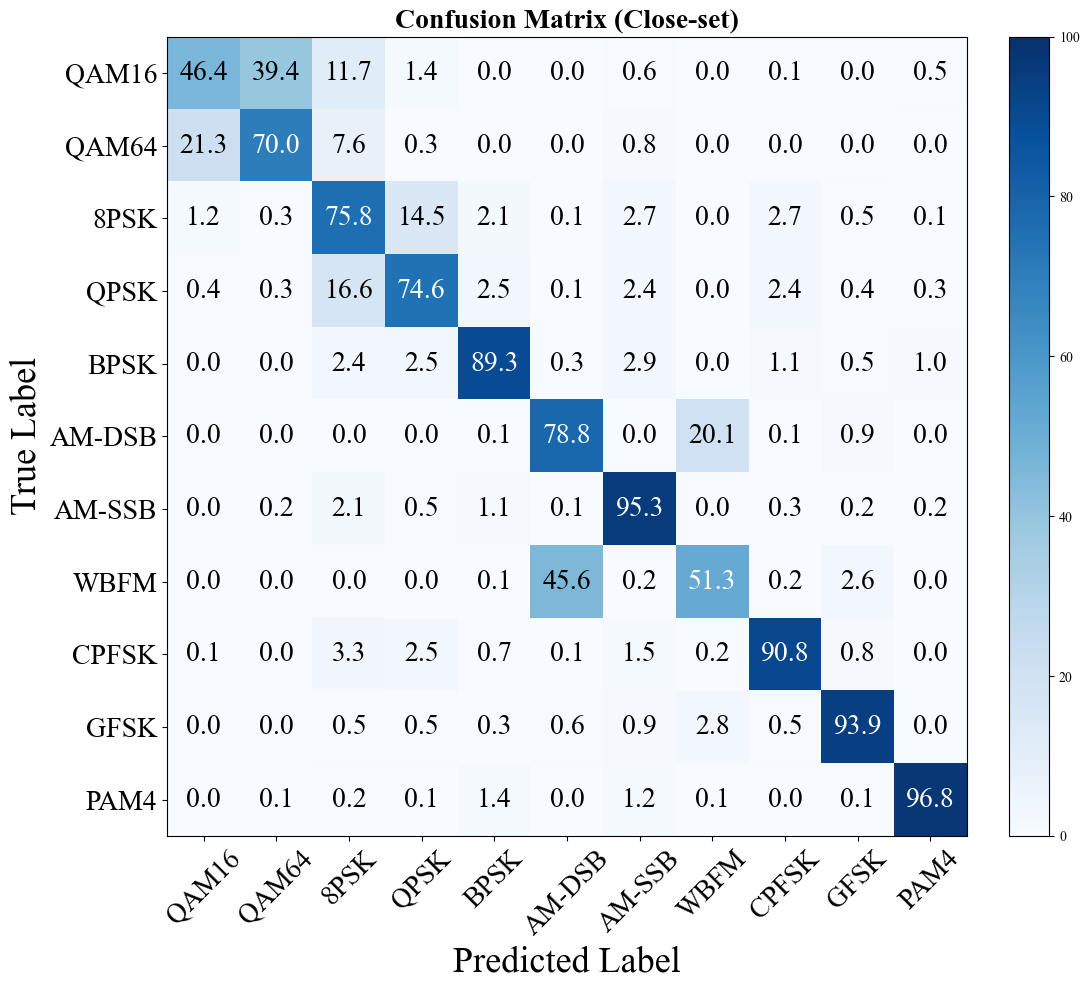

总体准确率: 0.7845

各类别性能指标:
类别         精确率        召回率        F1分数      
----------------------------------------
QAM16      0.6686     0.4635     0.5475    
QAM64      0.6346     0.7000     0.6657    
8PSK       0.6306     0.7580     0.6885    
QPSK       0.7701     0.7463     0.7580    
BPSK       0.9150     0.8931     0.9039    
AM-DSB     0.6269     0.7880     0.6983    
AM-SSB     0.8785     0.9530     0.9142    
WBFM       0.6886     0.5130     0.5880    
CPFSK      0.9246     0.9080     0.9162    
GFSK       0.9399     0.9389     0.9394    
PAM4       0.9788     0.9680     0.9734    


(array([[0.464, 0.394, 0.117, 0.014, 0.   , 0.   , 0.006, 0.   , 0.001,
         0.   , 0.005],
        [0.213, 0.7  , 0.076, 0.003, 0.   , 0.   , 0.008, 0.   , 0.   ,
         0.   , 0.   ],
        [0.012, 0.003, 0.758, 0.145, 0.021, 0.001, 0.027, 0.   , 0.027,
         0.005, 0.001],
        [0.004, 0.003, 0.166, 0.747, 0.025, 0.001, 0.024, 0.   , 0.024,
         0.004, 0.003],
        [0.   , 0.   , 0.024, 0.025, 0.894, 0.003, 0.029, 0.   , 0.011,
         0.005, 0.01 ],
        [0.   , 0.   , 0.   , 0.   , 0.001, 0.788, 0.   , 0.201, 0.001,
         0.009, 0.   ],
        [0.   , 0.002, 0.021, 0.005, 0.011, 0.001, 0.954, 0.   , 0.003,
         0.002, 0.002],
        [0.   , 0.   , 0.   , 0.   , 0.001, 0.456, 0.002, 0.513, 0.002,
         0.026, 0.   ],
        [0.001, 0.   , 0.033, 0.025, 0.007, 0.001, 0.015, 0.002, 0.908,
         0.008, 0.   ],
        [0.   , 0.   , 0.005, 0.005, 0.003, 0.006, 0.009, 0.028, 0.005,
         0.938, 0.   ],
        [0.   , 0.001, 0.002, 0.001, 0.0

In [18]:
#混淆矩阵
model = load_model(model, 'results/rml201610a_comix/best2.ckpt').to(device)
# 根据标签映射定义类别名称
class_names = ['QAM16', 'QAM64', '8PSK', 'QPSK', 'BPSK', 'AM-DSB', 'AM-SSB', 'WBFM', 'CPFSK', 'GFSK', 'PAM4']
plot_confusion_matrix_from_model(
    model=model,
    data_loader=test_loader,
    class_names=class_names,
    title='Confusion Matrix (Close-set)',   
    save_path=os.path.join(config_epa.save_dir, 'confusion_matrix_normalized.pdf'),
    figsize=(12, 10),
    normalize=True
)

In [ ]:
import os
import copy
from copy import deepcopy
import time
import glob
import random
import pickle
import collections
import itertools
import numpy as np
from tqdm import tqdm
from pathlib import Path
from scipy import stats
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphSAGE, global_mean_pool
from torch_geometric.data import Data, Batch
import numpy as np
from typing import List, Tuple
import math
from torch.utils.data import Dataset, DataLoader, Subset
from joypy import joyplot
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix
from sklearn.cluster import KMeans
from scipy.special import ive
from spherecluster import VonMisesFisherMixture
import sklearn.covariance

import openood.utils.comm as comm
from openood.utils import config
from openood.networks.resnet18_32x32 import ResNet18_32x32
from openood.datasets import get_dataloader, get_ood_dataloader
from openood.evaluators.metrics import compute_all_metrics
from openood.networks.vae import ConditionalVAE, weighted_average

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'  
plt.rcParams['axes.unicode_minus'] = False  

# 设备和随机种子配置
os.environ['PYTHONHASHSEED'] = str(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_acc = 0
best_epoch_idx = 0

class Config_gnn:
    def __init__(self):

        self.num_classes = 8  
        self.feature_dim = 512
        self.epochs = 100      
        self.batch_size = 128
        
        self.lr = 1e-1
        self.weight_decay = 1e-4
        self.momentum_opt = 0.9
        
        self.save_dir = "results/dtsg_rml201610a"
        self.device = device

        self.config_files = [
            './configs/datasets/rml201610a_comix/rml201610a.yml',
            './configs/networks/resnet18_32x32.yml',
            './configs/pipelines/test/test_ood.yml',
            './configs/preprocessors/base_preprocessor.yml',
            './configs/postprocessors/msp.yml',
        ]
        
        # DTSG-Net 
        self.signal_length = 128      # 信号长度
        self.patch_length = 16       # 每个patch的长度
        self.patch_stride = 8        # patch的步长
        self.local_window = 4         # 图连接的局部窗口大小
        self.gnn_hidden_dim = 128      # GNN隐藏层维度
        self.gnn_layers = 3           # GNN层数
        self.rnn_hidden_dim = 128     # RNN隐藏层维度
        self.rnn_layers = 2           # RNN层数
        self.rnn_type = 'GRU'        # RNN类型: 'LSTM' 或 'GRU'
        self.dropout = 0.1             # Dropout比率
        
class ETF_Classifier(nn.Module):
    def __init__(self, feat_in, num_classes):
        super(ETF_Classifier, self).__init__()
        effective_classes = num_classes   
        P = self.generate_random_orthogonal_matrix(feat_in, effective_classes)
        I = torch.eye(effective_classes)
        one = torch.ones(effective_classes, effective_classes)
        scaling_factor = np.sqrt(effective_classes / (effective_classes - 1))

        self.ori_M = scaling_factor * torch.matmul(P, I - (1.0 / effective_classes) * one).cuda()
        self.ori_M.requires_grad_(False)

    def generate_random_orthogonal_matrix(self, feat_in, num_classes):
        a = np.random.random(size=(feat_in, num_classes))
        P, _ = np.linalg.qr(a)
        P = torch.tensor(P).float()
        return P
    
    def orthogonal_complement(self):
        """使用施密特正交化计算权重矩阵的正交互补子空间"""
        # 获取权重矩阵的形状
        feat_dim = self.ori_M.shape[0]
        class_dim = self.ori_M.shape[1]
        
        # 首先获取权重矩阵的列向量作为初始子空间的基
        weight_basis = self.ori_M.T.cpu()  # 转置使每行成为一个基向量
        
        # 创建一组完整的基向量（包括单位向量）
        full_basis = torch.eye(feat_dim)
        
        # 使用施密特正交化过程找到正交互补子空间
        complement_basis = []
        
        for i in range(feat_dim):
            v = full_basis[i]
            
            # 检查v是否与权重子空间线性无关
            # 通过计算v与权重基向量的投影，然后检查剩余部分是否显著
            v_copy = v.clone()
            
            # 从v中减去它在权重基向量上的投影
            for w in weight_basis:
                v_copy = v_copy - torch.dot(v_copy, w) * w / torch.dot(w, w)
            
            # 如果剩余向量的范数足够大，则它是互补子空间的一部分
            if torch.norm(v_copy) > 1e-6:
                # 归一化
                v_copy = v_copy / torch.norm(v_copy)
                complement_basis.append(v_copy)
        
        # 将互补基向量堆叠成矩阵
        if complement_basis:
            orthogonal_complement = torch.stack(complement_basis)
        else:
            # 如果没有找到互补基向量，返回空矩阵
            orthogonal_complement = torch.zeros((0, feat_dim))
        
        return orthogonal_complement
    
    def project_to_complement(self, x):
        orthogonal_comp = self.orthogonal_complement().to(x.device)
        # 计算投影
        projection = torch.matmul(torch.matmul(x, orthogonal_comp.t()), orthogonal_comp)
        return projection
    
    def forward(self, x):

        logit = x @ self.ori_M 
        return logit

class DTSG(nn.Module):
    #信号->patch图
    def __init__(self, patch_length: int = 32, patch_stride: int = 32, 
                 local_window: int = 8, signal_length: int = 128):  
        super(DTSG, self).__init__()
        
        self.patch_length = patch_length
        self.patch_stride = patch_stride

        #图每个节点的有边上限数
        self.local_window = local_window 
        self.signal_length = signal_length
        
        #patch数量
        self.num_patches = ((signal_length - patch_length) // patch_stride) + 1

        #可训练的边权重
        self.edge_weights = nn.Parameter(torch.randn(local_window))
        
        # 初始化掩码矩阵 (用于构建稀疏邻接矩阵)
        self.register_buffer('adj_mask', self._create_adjacency_mask())
        
        # 预计算边索引和距离（所有patch的图结构相同，只需计算一次）
        self.register_buffer('edge_index', self._precompute_edge_index())
        self.register_buffer('edge_distance', self._precompute_edge_distance())
    
    #排除自己 连接前local_window个点和后local_window个点 局部
    def _create_adjacency_mask(self) -> torch.Tensor:
        # 向量化实现，避免循环
        i_indices = torch.arange(self.patch_length, dtype=torch.long).unsqueeze(1)
        j_indices = torch.arange(self.patch_length, dtype=torch.long).unsqueeze(0)
        distance = torch.abs(i_indices - j_indices)
        mask = ((distance > 0) & (distance <= self.local_window)).float()
        return mask
    
    def _precompute_edge_index(self) -> torch.Tensor:
        #无向图
        edge_list = []
        for i in range(self.patch_length):
            for j in range(self.patch_length):
                if 0 < abs(i - j) <= self.local_window:
                    edge_list.append([i, j])
        # 有向图
        # for i in range(self.patch_length):
        #     for j in range(i+1, min(i+self.local_window+1, self.patch_length)):
        #         edge_list.append([i, j])  # 只连接前向
        #         if len(edge_list) == 0:

        if len(edge_list) == 0:
            edge_list = [[i, i] for i in range(self.patch_length)]
        return torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    
    def _precompute_edge_distance(self) -> torch.Tensor:
        """预计算每条边的距离，用于索引edge_weights"""
        distances = []
        for i in range(self.patch_length):
            for j in range(self.patch_length):
                if 0 < abs(i - j) <= self.local_window:
                    distances.append(abs(i - j))
        if len(distances) == 0:
            distances = [1] * self.patch_length  # 自环距离设为1
        return torch.tensor(distances, dtype=torch.long) - 1  # 减1用于索引edge_weights


    ''' 有边
        adj_mask = [
        [0, 1, 1, 1, 0, 0, 0, 0],  # i=0: 连接节点1,2,3
        [1, 0, 1, 1, 1, 0, 0, 0],  # i=1: 连接节点0,2,3,4
        [1, 1, 0, 1, 1, 1, 0, 0],  # i=2: 连接节点0,1,3,4,5
        [1, 1, 1, 0, 1, 1, 1, 0],  # i=3: 连接节点0,1,2,4,5,6
        [0, 1, 1, 1, 0, 1, 1, 1],  # i=4: 连接节点1,2,3,5,6,7
        [0, 0, 1, 1, 1, 0, 1, 1],  # i=5: 连接节点2,3,4,6,7
        [0, 0, 0, 1, 1, 1, 0, 1],  # i=6: 连接节点3,4,5,7
        [0, 0, 0, 0, 1, 1, 1, 0],  # i=7: 连接节点4,5,6
    ]
    '''
    '''
        edge_index = [
            [0,1], [0,2], [0,3],           # 节点0的边
            [1,0], [1,2], [1,3], [1,4],    # 节点1的边
            [2,0], [2,1], [2,3], [2,4], [2,5],  # 节点2的边
            [3,0], [3,1], [3,2], [3,4], [3,5], [3,6],  # 节点3的边
            [4,1], [4,2], [4,3], [4,5], [4,6], [4,7],  # 节点4的边
            [5,2], [5,3], [5,4], [5,6], [5,7],  # 节点5的边
            [6,3], [6,4], [6,5], [6,7],   # 节点6的边
            [7,4], [7,5], [7,6],          # 节点7的边
    ]
        edge_attr = [
            0.5, 0.3, 0.1,              # 节点0的边权重
            0.5, 0.5, 0.3, 0.1,         # 节点1的边权重
            0.5, 0.5, 0.3, 0.3, 0.1,    # 节点2的边权重
            ...                          # 继续
    ]
    '''

    def _construct_patch_graph(self, patch_data: torch.Tensor) -> Data:
        """使用预计算的边索引和距离，避免重复计算"""
        node_features = patch_data
        
        # 使用预计算的边索引
        edge_index = self.edge_index
        
        # 使用预计算的距离索引edge_weights（向量化操作）
        edge_attr = self.edge_weights[self.edge_distance]
            
        return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)
    
    def forward(self, iq_signal: torch.Tensor) -> List[Data]:#将所有的patch转换为graph
        if iq_signal.dim() == 3 and iq_signal.shape[1] == 2:
            iq_signal = iq_signal.transpose(1, 2)  # [B, 2, L] -> [B, L, 2]
        
        batch_size = iq_signal.shape[0]
        device = iq_signal.device
        
        # 向量化提取所有patches: [B, num_patches, patch_length, 2]
        patches = []
        for patch_idx in range(self.num_patches):
            start_idx = patch_idx * self.patch_stride
            end_idx = start_idx + self.patch_length
            patch = iq_signal[:, start_idx:end_idx, :]  # [B, patch_length, 2]
            
            # 处理边界情况：如果patch长度不足，进行padding
            if patch.shape[1] < self.patch_length:
                padding = torch.zeros(batch_size, self.patch_length - patch.shape[1], 2,
                                     device=device)
                patch = torch.cat([patch, padding], dim=1)
            
            patches.append(patch)
        
        # 构建所有图（仍需要逐个构建Data对象，但避免了重复计算边结构）
        all_patch_graphs = []
        for patch in patches:  # [B, patch_length, 2]
            for b in range(batch_size):
                patch_data = patch[b]  # [patch_length, 2]
                patch_graph = self._construct_patch_graph(patch_data)
                all_patch_graphs.append(patch_graph)
        
        return all_patch_graphs

class PatchGNN(nn.Module):#目前还是patch级别
    def __init__(self, input_dim: int = 2, hidden_dim: int = 64, 
                 num_layers: int = 3, dropout: float = 0.1):
        super(PatchGNN, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gnn_layers = nn.ModuleList()
        self.gnn_layers.append(
            GraphSAGE(input_dim, hidden_dim, num_layers=1)#图采样和图聚合 
        )
        for _ in range(1, num_layers):
            self.gnn_layers.append(
                GraphSAGE(hidden_dim, hidden_dim, num_layers=1)
            )
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()
    
    def forward(self, batch_graph: Batch) -> torch.Tensor:
        '''
        edge_index = [
        [0, 0, 0, 1, 1, 1, ..., 31, 31, 31, 32, 32, ...],  # 源节点
        [1, 2, 3, 0, 2, 3, ..., 30, 31, 0, 33, 34, ...]   # 目标节点
        ]
        batch = [
        0, 0, 0, ..., 0,        # 前32个节点属于图0
        1, 1, 1, ..., 1,        # 接下来32个节点属于图1
        2, 2, 2, ..., 2,        # 接下来32个节点属于图2
        ...
        15, 15, 15, ..., 15    # 最后32个节点属于图15
        ]
        '''
        x, edge_index, batch = batch_graph.x, batch_graph.edge_index, batch_graph.batch
        
        # 如果有边属性，将其作为边权重
        edge_weight = getattr(batch_graph, 'edge_attr', None)#边权重
        
        # 通过GNN层
        for i, gnn_layer in enumerate(self.gnn_layers):
            x_new = gnn_layer(x, edge_index, edge_weight=edge_weight)
            x_new = self.layer_norms[i](x_new)
            x_new = self.activation(x_new)
            x_new = self.dropout(x_new)
            
            # 残差连接
            if i > 0 and x.shape == x_new.shape:
                x = x + x_new
            else:
                x = x_new
        
        # 图级读出 (平均池化)
        graph_features = global_mean_pool(x, batch)
        
        # 输出投影
        graph_features = self.output_proj(graph_features)
        graph_features = self.activation(graph_features)
        
        return graph_features

class TemporalRNN(nn.Module):#patch序列->时序特征   横向
    def __init__(self, input_dim: int = 64, hidden_dim: int = 128, 
                 num_layers: int = 2, rnn_type: str = 'LSTM', dropout: float = 0.1):
        super(TemporalRNN, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.rnn_type = rnn_type
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0,
                bidirectional=False
            )
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(
                input_size=input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0,
                bidirectional=False
            )
        else:
            raise ValueError(f"Unsupported RNN type: {rnn_type}")
        
        # 层归一化
        # self.layer_norm = nn.LayerNorm(hidden_dim)
        # self.dropout = nn.Dropout(dropout)
    
    def forward(self, patch_features: torch.Tensor, num_patches: int) -> torch.Tensor:
        """
            patch_features: [batch_size * num_patches, hidden_dim]

            [batch_size, hidden_dim] 时序特征
        """
        batch_size = patch_features.shape[0] // num_patches
        
        # 重塑为序列形式 [batch_size, num_patches, feature_dim]
        sequence_features = patch_features.view(batch_size, num_patches, -1)
        
        # 通过RNN
        if self.rnn_type == 'LSTM':
            output, (hidden, _) = self.rnn(sequence_features)
        else:  # GRU
            output, hidden = self.rnn(sequence_features)
        
        # 使用最后一个时间步的输出作为序列表示（更好的梯度流）
        # output: [batch_size, num_patches, hidden_dim]
        # 使用output[:, -1, :]而不是hidden[-1]，因为output是经过所有层处理后的最终输出
        sequence_representation = output[:, -1, :]  # [batch_size, hidden_dim]
        
        # sequence_representation = self.layer_norm(sequence_representation)
        # sequence_representation = self.dropout(sequence_representation)
        
        return sequence_representation

class DTSGNet(nn.Module):
    def __init__(self, num_classes: int = 8, signal_length: int = 128,
                 patch_length: int = 32, patch_stride: int = 32,
                 local_window: int = 8, gnn_hidden_dim: int = 64,
                 gnn_layers: int = 3, rnn_hidden_dim: int = 128,
                 rnn_layers: int = 2, rnn_type: str = 'LSTM',
                 dropout: float = 0.1):
        super(DTSGNet, self).__init__()
        
        self.signal_length = signal_length
        self.patch_length = patch_length
        self.patch_stride = patch_stride
        self.num_patches = ((signal_length - patch_length) // patch_stride) + 1
        
        self.dtsg = DTSG(
            patch_length=patch_length,
            patch_stride=patch_stride,
            local_window=local_window,
            signal_length=signal_length
        )
        
        self.patch_gnn = PatchGNN(
            input_dim=2, 
            hidden_dim=gnn_hidden_dim,
            num_layers=gnn_layers,
            dropout=dropout
        )
        
        self.temporal_rnn = TemporalRNN(
            input_dim=gnn_hidden_dim,
            hidden_dim=rnn_hidden_dim,
            num_layers=rnn_layers,
            rnn_type=rnn_type,
            dropout=dropout
        )

        #fc
        self.classifier = nn.Sequential(
            nn.Linear(rnn_hidden_dim, rnn_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(rnn_hidden_dim // 2, num_classes)
        )

        #etf
        self.etf_classifier = ETF_Classifier(feat_in=rnn_hidden_dim, num_classes=num_classes)
        
       
    def forward(self, iq_signal: torch.Tensor) -> torch.Tensor:
        batch_size = iq_signal.shape[0]
        device = iq_signal.device
        
        patch_graphs = self.dtsg(iq_signal)#[32,2]  896   strid =16 len=128 (128-16)/32(window)
        batch_graph = Batch.from_data_list(patch_graphs).to(device)  
        patch_features = self.patch_gnn(batch_graph)  
        # temporal_features = self.temporal_rnn(patch_features, self.num_patches)
        #fc
        # logits = self.classifier(temporal_features)
        #etf
        logits = self.etf_classifier(patch_features)
        return logits

class DTSGTrainer(nn.Module):
    """DTSG-Net训练器"""
    def __init__(self, net: nn.Module, train_loader: DataLoader, config_gnn) -> None:
        super(DTSGTrainer, self).__init__()
        self.net = net
        self.train_loader = train_loader
        self.config_gnn = config_gnn
        
        # Optimizer
        self.optimizer = torch.optim.Adam(
            net.parameters(),
            lr=config_gnn.lr,
            weight_decay=config_gnn.weight_decay
        )
        
        def cosine_annealing(step, total_steps, lr_max, lr_min):
            return lr_min + (lr_max - lr_min) * 0.5 * \
                        (1 + np.cos(step / total_steps * np.pi))
        
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=lambda step: cosine_annealing(
                step,
                config_gnn.epochs * len(train_loader),
                1,
                1e-6 / config_gnn.lr,
            ),
        )
        
        self.ce = nn.CrossEntropyLoss()
    
    def train_epoch(self, epoch_idx):
        self.net.train()
        total_loss = 0.0
        correct = 0
        total = 0
        
        for batch in tqdm(self.train_loader, desc=f'Train Epoch {epoch_idx}'):
            data = batch['data'].to(self.config_gnn.device).squeeze(1)
            target = batch['label'].to(self.config_gnn.device)
            

            self.optimizer.zero_grad()
            logits = self.net(data)
            loss = self.ce(logits, target)
            loss.backward()
        
            self.optimizer.step()
            self.scheduler.step()
            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(target).sum().item()
            total += target.size(0)
        
        metrics = {
            'epoch_idx': epoch_idx,
            'loss': total_loss / len(self.train_loader),
            'acc': correct / total
        }
        return metrics

class DTSGTrainingManager:
    def __init__(self, config_gnn):
        self.config_gnn = config_gnn
        self.device = config_gnn.device
        self.train_losses = []
        self.val_accuracies = []
        self.ce = nn.CrossEntropyLoss()
        
    def train(self, train_loader, val_loader):
        model = DTSGNet(
            num_classes=self.config_gnn.num_classes,
            signal_length=self.config_gnn.signal_length,
            patch_length=self.config_gnn.patch_length,
            patch_stride=self.config_gnn.patch_stride,
            local_window=self.config_gnn.local_window,
            gnn_hidden_dim=self.config_gnn.gnn_hidden_dim,
            gnn_layers=self.config_gnn.gnn_layers,
            rnn_hidden_dim=self.config_gnn.rnn_hidden_dim,
            rnn_layers=self.config_gnn.rnn_layers,
            rnn_type=self.config_gnn.rnn_type,
            dropout=self.config_gnn.dropout
        ).to(self.config_gnn.device)
        
        trainer = DTSGTrainer(model, train_loader, self.config_gnn)
        model = model.to(self.config_gnn.device)
        trainer = trainer.to(self.config_gnn.device)  
        print("Starting DTSG-Net training...")        
        for epoch in range(1, self.config_gnn.epochs + 1):

            train_metrics = trainer.train_epoch(epoch)
            val_metrics = self.validate(model, val_loader, epoch)         
            self.save_model(model, val_metrics, self.config_gnn.epochs)         
            self.report(train_metrics, val_metrics)      
        return model, trainer
    
    def validate(self, model, val_loader, epoch_idx):
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Val Epoch {epoch_idx}'):
                data = batch['data'].to(self.device).squeeze(1)
                target = batch['label'].to(self.device)
                
                logits = model(data)
                loss = F.cross_entropy(logits, target)
                
                val_loss += loss.item()
                _, predicted = logits.max(1)
                correct += predicted.eq(target).sum().item()
                total += target.size(0)  
        
        metrics = {
            'epoch_idx': epoch_idx,
            'loss': val_loss / len(val_loader),
            'acc': correct / total
        }
        return metrics
    
    def save_model(self, net, val_metrics, num_epochs):
        global best_acc, best_epoch_idx
        output_dir = self.config_gnn.save_dir
        os.makedirs(output_dir, exist_ok=True)
        
        try:
            state_dict = net.module.state_dict()
        except AttributeError:
            state_dict = net.state_dict()
        
        if val_metrics['acc'] >= best_acc:
            old_fname = f'best_epoch{best_epoch_idx}_acc{best_acc:.4f}.ckpt'
            old_pth = os.path.join(output_dir, old_fname)
            Path(old_pth).unlink(missing_ok=True)
            
            best_epoch_idx = val_metrics['epoch_idx']
            best_acc = val_metrics['acc']
            
            torch.save(state_dict, os.path.join(output_dir, 'best.ckpt'))
            save_fname = f'best_epoch{best_epoch_idx}_acc{best_acc:.4f}.ckpt'
            torch.save(state_dict, os.path.join(output_dir, save_fname))
            print(f"Best model saved: {save_fname}")
        
        if val_metrics['epoch_idx'] == num_epochs:
            save_fname = f'last_epoch{val_metrics["epoch_idx"]}_acc{val_metrics["acc"]:.4f}.ckpt'
            torch.save(state_dict, os.path.join(output_dir, save_fname))
            print(f"Final model saved: {save_fname}")
    
    def report(self, train_metrics, val_metrics):
        """Training progress report"""
        print('\n  Epoch {:03d} | Train Loss {:.4f} | '
              'Val Loss {:.3f} | Val Acc {:.2f}%'.format(
                  train_metrics['epoch_idx'],
                  train_metrics['loss'],
                  val_metrics['loss'],
                  100.0 * val_metrics['acc'],
              ),
              flush=True)

def get_predictions(model, data_loader, device):
    """获取模型在数据加载器上的预测结果"""
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            data = batch['data'].to(device).squeeze(1)
            labels = batch['label'].to(device)
            
            logits = model(data)
            _, pred = torch.max(logits, dim=1)
            
            all_predictions.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels)

def plot_confusion_matrix(y_true, y_pred, class_names=None, title='Confusion Matrix', 
                         save_path=None, figsize=(10, 8), normalize=False):
    """
    绘制混淆矩阵
    
    Args:
        y_true: 真实标签
        y_pred: 预测标签
        class_names: 类别名称列表
        title: 图表标题
        save_path: 保存路径，如果为None则不保存
        figsize: 图像大小
        normalize: 是否归一化显示百分比
    """
    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm = np.round(cm, 3)
    
    # 如果没有提供类别名称，使用数字标签
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(np.unique(y_true)))]
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 绘制热力图
    im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    # 设置坐标轴
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=0, ha='right')
    plt.yticks(tick_marks, class_names)
    
    # 添加数值标注（显示为百分比格式）
    # 计算百分比（按行归一化）
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        # 格式化为保留一位小数的百分比
        text = f'{cm_percent[i, j]:.1f}%'
        plt.text(j, i, text,
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)
    
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    
    # 保存图像
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"混淆矩阵已保存到: {save_path}")
    
    plt.show()
    
    # 计算并打印准确率
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"总体准确率: {accuracy:.4f}")
    
    # 计算每个类别的精确率、召回率和F1分数
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    f1 = 2 * precision * recall / (precision + recall)
    
    # 处理除零情况
    precision = np.nan_to_num(precision)
    recall = np.nan_to_num(recall)
    f1 = np.nan_to_num(f1)
    
    print("\n各类别性能指标:")
    print(f"{'类别':<15} {'精确率':<10} {'召回率':<10} {'F1分数':<10}")
    print("-" * 45)
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<15} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1[i]:<10.4f}")
    
    return cm, accuracy, precision, recall, f1

def plot_confusion_matrix_from_model(model, data_loader, class_names=None, 
                                   title='Confusion Matrix', save_path=None, 
                                   figsize=(10, 8), normalize=False, device=None):
    """
    直接从模型和数据加载器绘制混淆矩阵
    
    Args:
        model: 训练好的模型
        data_loader: 数据加载器
        class_names: 类别名称列表
        title: 图表标题
        save_path: 保存路径
        figsize: 图像大小
        normalize: 是否归一化显示百分比
        device: 设备
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("正在获取预测结果...")
    y_pred, y_true = get_predictions(model, data_loader, device)
    
    return plot_confusion_matrix(y_true, y_pred, class_names, title, 
                               save_path, figsize, normalize)

def test_and_plot_confusion_matrix(checkpoint_path=None, class_names=None, normalize=True):
    """
    加载训练好的模型并在测试集上绘制混淆矩阵
    
    Args:
        checkpoint_path: 模型检查点路径，如果为None则使用默认路径
        class_names: 类别名称列表，如果为None则使用默认名称
        normalize: 是否归一化显示百分比
    """
    config_gnn = Config_gnn()
    configopenood = config.Config(*config_gnn.config_files)
    
    # 获取测试数据加载器
    loader_dict = get_dataloader(configopenood)
    test_loader = loader_dict['test']
    
    # 创建模型
    model = DTSGNet(
        num_classes=config_gnn.num_classes,
        signal_length=config_gnn.signal_length,
        patch_length=config_gnn.patch_length,
        patch_stride=config_gnn.patch_stride,
        local_window=config_gnn.local_window,
        gnn_hidden_dim=config_gnn.gnn_hidden_dim,
        gnn_layers=config_gnn.gnn_layers,
        rnn_hidden_dim=config_gnn.rnn_hidden_dim,
        rnn_layers=config_gnn.rnn_layers,
        rnn_type=config_gnn.rnn_type,
        dropout=config_gnn.dropout
    ).to(config_gnn.device)
    
    # 加载训练好的模型
    if checkpoint_path is None:
        checkpoint_path = os.path.join(config_gnn.save_dir, 'best.ckpt')
    
    if os.path.exists(checkpoint_path):
        print(f"Loading model from {checkpoint_path}")
        state_dict = torch.load(checkpoint_path, map_location=config_gnn.device)
        model.load_state_dict(state_dict)
        print("Model loaded successfully!")
    else:
        print(f"Model checkpoint not found at {checkpoint_path}")
        print("Available files in save directory:")
        if os.path.exists(config_gnn.save_dir):
            for file in os.listdir(config_gnn.save_dir):
                print(f"  - {file}")
        return None
    
    model = model.to(config_gnn.device)
    model.eval()
    
    # 设置类别名称
    if class_names is None:
        class_names = ['QAM16', 'QAM64', '8PSK', 'QPSK', 'BPSK', 'AM-DSB', 'AM-SSB', 'WBFM']
    
    print(f"Class mapping: {dict(enumerate(class_names))}")
    
    # 绘制混淆矩阵
    save_path = os.path.join(config_gnn.save_dir, 'confusion_matrix_normalized.png' if normalize else 'confusion_matrix.png')
    cm, accuracy, precision, recall, f1 = plot_confusion_matrix_from_model(
        model=model,
        data_loader=test_loader,
        class_names=class_names,
        title='Normalized Confusion Matrix' if normalize else 'Confusion Matrix',
        save_path=save_path,
        figsize=(12, 10),
        normalize=normalize,
        device=config_gnn.device
    )
    
    return cm, accuracy, precision, recall, f1

def load_model(model,checkpoint_path):
    state_dict = torch.load(checkpoint_path)
    model.load_state_dict(state_dict)
    return model 

if __name__ == '__main__':
    config_gnn = Config_gnn()
    configopenood = config.Config(*config_gnn.config_files)
    os.makedirs(config_gnn.save_dir, exist_ok=True)
    
    # Get data loaders
    loader_dict = get_dataloader(configopenood)
    train_loader = loader_dict['train']
    val_loader = loader_dict['val']
    test_loader = loader_dict['test']
    
    #train
    # training_manager = DTSGTrainingManager(config_gnn)
    # trained_model, trainer = training_manager.train(train_loader, val_loader)
    


    #confusion_matrix
    cm, accuracy, precision, recall, f1 = test_and_plot_confusion_matrix(
        checkpoint_path=None,  # 使用默认路径 results/dtsg_rml201610a/best.ckpt
        class_names=None,  # 使用默认类别名称
        normalize=True  # 归一化显示百分比
    )

    print("\n" + "="*60)
    print("Training completed!")
    print(f"Best accuracy: {best_acc:.4f}")
    print(f"Best epoch: {best_epoch_idx}")
    print(f"Model saved to: {config_gnn.save_dir}")